<a href="https://colab.research.google.com/github/rodrigoriverae-coder/sql-python-data-analysis-practice/blob/main/03-proyecto-adventureworks-python/notebooks/03_analisis_ventas_adventureworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

datos = {
    'SalesOrderID': [43659, 43660, 43661, 43662, 43663],
    'Status': [5, 5, 5, 6, 5],
    'TotalDue': [20565.18, 1294.25, 32726.47, 500.00, 714.70]
}

df = pd.DataFrame(datos)

df

,SalesOrderID,Status,TotalDue
0,43659,5,20565.18
1,43660,5,1294.25
2,43661,5,32726.47
3,43662,6,500.00
4,43663,5,714.70


In [ ]:
df[df['TotalDue'] > 1000]

,SalesOrderID,Status,TotalDue
0,43659,5,20565.18
1,43660,5,1294.25
2,43661,5,32726.47


In [ ]:
df[(df['Status'] == 5) & (df['TotalDue'] > 1000)]

,SalesOrderID,Status,TotalDue
0,43659,5,20565.18
1,43660,5,1294.25
2,43661,5,32726.47


In [ ]:
df.sort_values(by='TotalDue', ascending=False)

,SalesOrderID,Status,TotalDue
2,43661,5,32726.47
0,43659,5,20565.18
1,43660,5,1294.25
4,43663,5,714.70
3,43662,6,500.00


In [ ]:
df[(df['Status'] == 5) & (df['TotalDue'] > 1000)].sort_values(by='TotalDue',ascending=False).head(2)

,SalesOrderID,Status,TotalDue
2,43661,5,32726.47
0,43659,5,20565.18


In [ ]:
datos = {
    'SalesOrderID': [43659, 43660, 43661, 43662, 43663, 43664],
    'CustomerID': [11000, 11000, 11001, 11001, 11000, 11002],
    'Status': [5, 5, 5, 5, 5, 5],
    'TotalDue': [2000, 1500, 3000, 4000, 500, 1200]
}

df = pd.DataFrame(datos)
df

,SalesOrderID,CustomerID,Status,TotalDue
0,43659,11000,5,2000
1,43660,11000,5,1500
2,43661,11001,5,3000
3,43662,11001,5,4000
4,43663,11000,5,500
5,43664,11002,5,1200


In [ ]:
df.groupby('CustomerID')['TotalDue'].sum().reset_index()

,CustomerID,TotalDue
0,11000,4000
1,11001,7000
2,11002,1200


In [ ]:
df.groupby('CustomerID').agg(
    MontoTotal=('TotalDue', 'sum'),
    TotalOrdenes=('SalesOrderID', 'count'),MontoPromedio=('TotalDue',lambda x: round(x.mean(),2))
).reset_index()

,CustomerID,MontoTotal,TotalOrdenes,MontoPromedio
0,11000,4000,3,1333.33
1,11001,7000,2,3500.00
2,11002,1200,1,1200.00


In [ ]:
df_resumen = df.groupby('CustomerID').agg(
    MontoTotal=('TotalDue', 'sum'),
    TotalOrdenes=('SalesOrderID', 'count')
).reset_index()

datos_clientes = {
    'CustomerID': [11000, 11001, 11002],
    'NombreCliente': ['Jon Yang', 'Eugene Huang', 'Ruben Torres']
}
df_clientes = pd.DataFrame(datos_clientes)

In [ ]:
df_final = pd.merge(df_resumen, df_clientes, on='CustomerID', how='inner')
df_final

,CustomerID,MontoTotal,TotalOrdenes,NombreCliente
0,11000,4000,3,Jon Yang
1,11001,7000,2,Eugene Huang
2,11002,1200,1,Ruben Torres


In [ ]:
import pandas as pd

# Lectura
df_orders = pd.read_csv('SalesOrderHeader.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')
df_details = pd.read_csv('SalesOrderDetail.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')
df_products = pd.read_csv('Product.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')

# Limpieza rápida de espacios
df_orders.columns = df_orders.columns.str.strip()

# Verificación de desglose de columnas
print("Columnas de Orders:", df_orders.columns.tolist()[:5])
print("Dimensiones reales de Orders:", df_orders.shape)

Columnas de Orders: ['SalesOrderID', 'RevisionNumber', 'OrderDate', 'DueDate', 'ShipDate']
Dimensiones reales de Orders: (31465, 26)


In [ ]:
# Top 5 Ventas Más Altas

# 1. Ventas aprobadas (Status == 5)
df_aprobadas = df_orders[df_orders['Status'] == 5]

# 2. Top 5
top_5_ventas = df_aprobadas.sort_values(by='TotalDue', ascending=False).head(5)

# 3. Visualización de columnas clave
top_5_ventas[['SalesOrderID', 'CustomerID', 'Status', 'TotalDue']]

,SalesOrderID,CustomerID,Status,TotalDue
3007,46666,29594,5,"99952,438"
5086,48745,29937,5,"9994,9128"
21590,65249,29572,5,"9983,2209"
15826,59485,11356,5,"997,7929"
21402,65061,18943,5,"997,7929"


In [ ]:
# Top 5 Clientes que más dinero gastaron

# 1. Conversión de TotalDue a numérico
df_orders['TotalDue'] = df_orders['TotalDue'].astype(str).str.replace(',', '.').astype(float)

# 2. Agrupación
df_top_clientes = df_orders.groupby('CustomerID')['TotalDue'].sum().reset_index()
df_top_clientes = df_top_clientes.rename(columns={'TotalDue': 'MontoTotalAcumulado'})
df_top_clientes = df_top_clientes.sort_values(by='MontoTotalAcumulado', ascending=False).head(5)

df_top_clientes

,CustomerID,MontoTotalAcumulado
18818,29818,989184.0820
18715,29715,961675.8596
18722,29722,954021.9235
19117,30117,919801.8188
18614,29614,901346.8560


In [ ]:
# Unión de Tablas

# 1. Conversión de OrderQty a numérico
df_details['OrderQty'] = pd.to_numeric(df_details['OrderQty'], errors='coerce')

# 2. JOIN entre los detalles de la orden y la tabla de productos
df_ventas_prod = pd.merge(df_details, df_products, on='ProductID', how='inner')

# 3. Agrupar por nombre del producto y sumar las unidades vendidas
top_productos = df_ventas_prod.groupby('Name')['OrderQty'].sum().reset_index()

# 4. Ordenar de mayor a menor, tomar el Top 5 y reiniciar el índice
top_productos = top_productos.sort_values(by='OrderQty', ascending=False).head(5).reset_index(drop=True)

top_productos

,Name,OrderQty
0,AWC Logo Cap,8311
1,Water Bottle - 30 oz.,6815
2,"Sport-100 Helmet, Blue",6743
3,"Long-Sleeve Logo Jersey, L",6592
4,"Sport-100 Helmet, Black",6532


In [ ]:
# Ventas por Categoria de Producto

import pandas as pd

# 1. Convertimos UnitPrice
df_details['UnitPrice'] = df_details['UnitPrice'].astype(str).str.replace(',', '.').astype(float)
df_details['OrderQty'] = pd.to_numeric(df_details['OrderQty'], errors='coerce')

# 2. Calculamos el MontoLinea
df_details['MontoLinea'] = df_details['OrderQty'] * df_details['UnitPrice']

# 3. Hacemos el JOIN con la tabla de productos
df_details_products = pd.merge(df_details, df_products, on='ProductID', how='inner')

# 4. Agrupamos por producto, sumamos y mostramos el Top 10
df_ventas_categoria = df_details_products.groupby('Name')['MontoLinea'].sum().reset_index()
df_ventas_categoria = df_ventas_categoria.sort_values(by='MontoLinea', ascending=False).head(10).reset_index(drop=True)

df_ventas_categoria

,Name,MontoLinea
0,"Mountain-200 Black, 38",4.406151e+06
1,"Mountain-200 Black, 42",4.014068e+06
2,"Mountain-200 Silver, 38",3.696486e+06
3,"Mountain-200 Silver, 42",3.441293e+06
4,"Mountain-200 Silver, 46",3.436091e+06
5,"Mountain-200 Black, 46",3.311098e+06
6,"Road-250 Black, 44",2.518300e+06
7,"Road-250 Black, 48",2.348246e+06
8,"Road-250 Black, 52",2.012448e+06
9,"Road-150 Red, 56",1.847819e+06


In [ ]:
# Análisis temporal - Ventas por año y mes

import pandas as pd

# 1. Cargar el encabezado de ventas
df_header = pd.read_csv('SalesOrderHeader.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')
df_header.columns = df_header.columns.str.strip()

# 2. Convertir OrderDate a formato datetime
df_header['OrderDate'] = pd.to_datetime(df_header['OrderDate'], errors='coerce')

# 3. Limpiar y convertir SubTotal / TotalDue
df_header['SubTotal'] = df_header['SubTotal'].astype(str).str.replace(',', '.').astype(float)
df_header['TotalDue'] = df_header['TotalDue'].astype(str).str.replace(',', '.').astype(float)
df_header['TotalDue'] = df_header['TotalDue'].round(2)

# 4. Extraer Año, Mes y Año-Mes
df_header['Año'] = df_header['OrderDate'].dt.year
df_header['Mes'] = df_header['OrderDate'].dt.month

# Mostrar las primeras filas con las nuevas columnas de tiempo
df_header[['SalesOrderID', 'OrderDate', 'Año', 'Mes', 'TotalDue']].head()

,SalesOrderID,OrderDate,Año,Mes,TotalDue
0,43659,2022-05-30,2022,5,23153.23
1,43660,2022-05-30,2022,5,1457.33
2,43661,2022-05-30,2022,5,36865.80
3,43662,2022-05-30,2022,5,32474.93
4,43663,2022-05-30,2022,5,472.31


In [ ]:
# Análisis de Ventas Anuales

ventas_anuales = df_header.groupby('Año').agg(
    Total_Ventas=('TotalDue', lambda x: round(x.sum(),2)),
    Total_Ordenes=('SalesOrderID', 'count'),
    Ticket_Promedio=('TotalDue',lambda x: round(x.mean(),2))
).reset_index()

ventas_anuales

,Año,Total_Ventas,Total_Ordenes,Ticket_Promedio
0,2022,16316694.74,1692,9643.44
1,2023,35514704.62,3830,9272.77
2,2024,49020482.23,14244,3441.48
3,2025,22364897.96,11699,1911.69


In [ ]:
# Meses con mayor facturación global

ventas_mensuales = df_header.groupby('Mes').agg(
    Total_Ventas=('TotalDue', 'sum'),
    Total_Ordenes=('SalesOrderID', 'count')
).reset_index()

ventas_mensuales = ventas_mensuales.sort_values(by='Total_Ventas', ascending=False).reset_index(drop=True)

ventas_mensuales['Total_Ventas'] = ventas_mensuales['Total_Ventas'].apply(lambda x: f"{x:.2f}")

ventas_mensuales

,Mes,Total_Ventas,Total_Ordenes
0,3,12748068.91,3051
1,6,12614619.21,2253
2,9,12156590.17,2398
3,7,11255140.44,2355
4,10,10803898.80,2531
5,4,10560673.08,2974
6,12,10552782.37,2699
7,5,9815882.39,2994
8,1,9448861.42,2795
9,2,8238091.67,2406


/tmp/ipykernel_2996/3800334231.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_anuales, x='Año', y='Total_Ventas', ax=axes[0], palette='Blues_d')


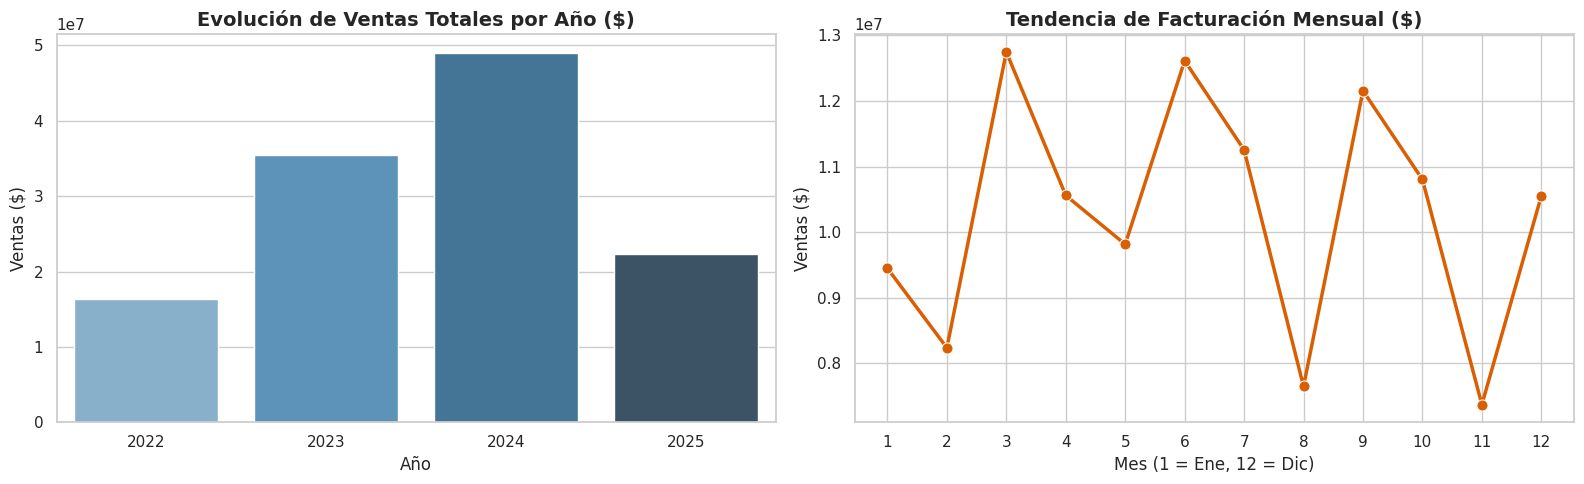

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Aseguramos que Total_Ventas sea numérico puro
ventas_mensuales['Total_Ventas_Num'] = ventas_mensuales['Total_Ventas'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
ventas_mensuales['Total_Ventas_Num'] = pd.to_numeric(ventas_mensuales['Total_Ventas_Num'], errors='coerce')

# 2. Ordenamos secuencialmente por número de mes (1 al 12)
ventas_mes_ordenado = ventas_mensuales.sort_values(by='Mes').reset_index(drop=True)

# 3. Lienzo de gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Ventas por Año
sns.barplot(data=ventas_anuales, x='Año', y='Total_Ventas', ax=axes[0], palette='Blues_d')
axes[0].set_title('Evolución de Ventas Totales por Año ($)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ventas ($)')
axes[0].set_xlabel('Año')

# Gráfico 2: Tendencia de Facturación Mensual (Numérica)
sns.lineplot(data=ventas_mes_ordenado, x='Mes', y='Total_Ventas_Num', ax=axes[1], marker='o', color='#d95f02', linewidth=2.5, markersize=8)
axes[1].set_title('Tendencia de Facturación Mensual ($)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Ventas ($)')
axes[1].set_xlabel('Mes (1 = Ene, 12 = Dic)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# 1. Exportar resúmenes a CSV
ventas_anuales.to_csv('ventas_anuales_summary.csv', index=False)
ventas_mes_ordenado.to_csv('ventas_mensuales_summary.csv', index=False)
df_ventas_categoria.to_csv('top10_productos_summary.csv', index=False)

# 2. Descargar automáticamente a la PC
files.download('ventas_anuales_summary.csv')
files.download('ventas_mensuales_summary.csv')
files.download('top10_productos_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>